In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

from gamma.cutcount import (
    CeAcCutCountConfig,
    EnergyWindowSpec,
    estimate_ceac_mixture_cutcount,
    estimate_single_isotope_cutcount
)
from gamma.efficiency import EfficiencyFitSpec, fit_efficiency_model
from gamma.artifacts import ArtifactStore


In [46]:
### For Viz
#Default plot parameters
pltmap = plt.get_cmap("tab10")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [4]:
store = ArtifactStore(repo_root / "artifacts")

# Build Config

In [5]:
cfg = CeAcCutCountConfig(
    ce_window=EnergyWindowSpec(center_keV=1022.0, resolution_pct_fwhm=8.0, nsigma=2.0),
    ac_window=EnergyWindowSpec(center_keV=440.0,  resolution_pct_fwhm=8.0, nsigma=2.0),  # or 218.0
)

# Load Calibrated Experiments

In [6]:
exp_mix = "ANIL_MIX_SD__agg__bkgsub"
exp_ce  = "ANIL_CE_SD__agg__bkgsub"
exp_ac  = "ANIL_AC_SD__agg__bkgsub"
cal_tag = "peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1"

mix_cal = store.load_calibration(exp_mix, cal_tag)
ce_cal  = store.load_calibration(exp_ce,  cal_tag)
ac_cal  = store.load_calibration(exp_ac,  cal_tag)

C:\Users\pomar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


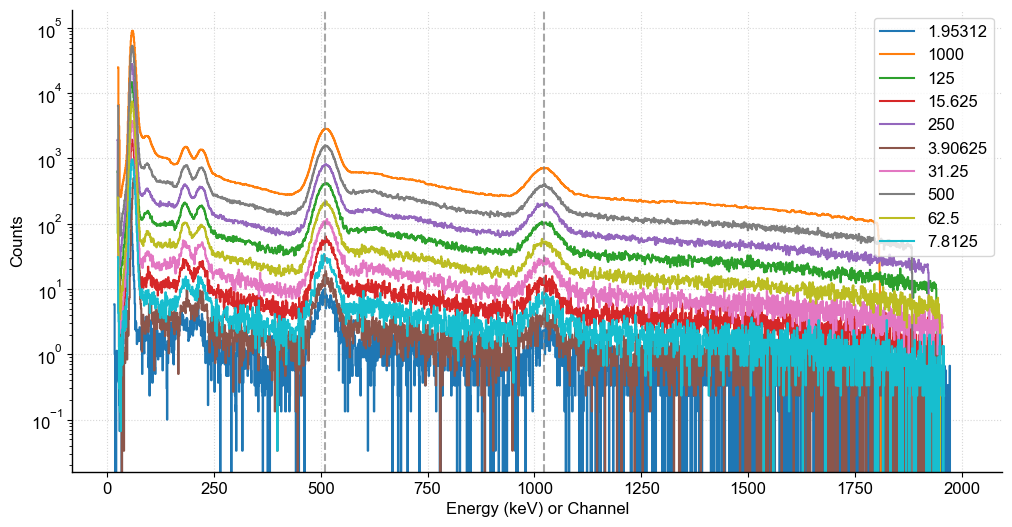

In [7]:
labels_to_plot = list(ce_cal.calibrated.keys())[:]

for label in labels_to_plot:
    obj = ce_cal.calibrated[label]
    # schema = obj.get("meta", {}).get("schema")
    # if schema != "bq_v1":
    #     raise RuntimeError(f"Need calibrated spectra (schema=bq_v1) for efficiency; got {schema!r}")
    # display(obj)
    x = obj['bin_centers_kev']
    y = obj['counts_vals']
    plt.step(x, y, where="mid", label=label)

    goods = (x > 972) * (x < 1072) # looking 50 channels above and below the 1022 keV peak
    window = obj['counts_vals'][goods]
    integrated_window = sum(window)
    
plt.yscale("log")
plt.xlabel("Energy (keV) or Channel")
plt.ylabel("Counts")
plt.legend()
# plt.axvline(AC_Fr_Peak, color='gray', ls='--', alpha=0.7)
# plt.axvline(AC_Bi_Peak, color='gray', ls='--', alpha=0.7)
plt.axvline(511, color='gray', ls='--', alpha=0.7)
plt.axvline(1022, color='gray', ls='--', alpha=0.7)
# plt.title(f"Loaded-from-artifacts calibrated spectra: {anil_ce_cal.experiment_id}")
plt.show()


# Example: Load Templates

In [34]:
mix_label = mix_cal.labels[4]
ce_template_label = ce_cal.labels[1]

print(f"Mix label: {mix_label}")
print(f"Ce template label: {ce_template_label}")

mix_spec = mix_cal.calibrated[mix_label]
ce_tpl   = ce_cal.calibrated[ce_template_label]

Mix label: 3.906:3.906
Ce template label: 1000


In [35]:
mix_spec

{'counts_vals': array([12.5,  6. ,  0. , ...,  0. ,  0. ,  0. ]),
 'bin_centers_kev': array([   3.12800688,    4.1261477 ,    5.12423876, ..., 1940.33460399,
        1941.230992  , 1942.12733025]),
 'meta': {'kind': 'Spectrum',
  'livetime': 60.0,
  'schema': 'bq_v1',
  'x_attr': 'bin_centers_kev',
  'x_units': 'keV',
  'y_attr': 'counts_vals'}}

### Visualize Choice:

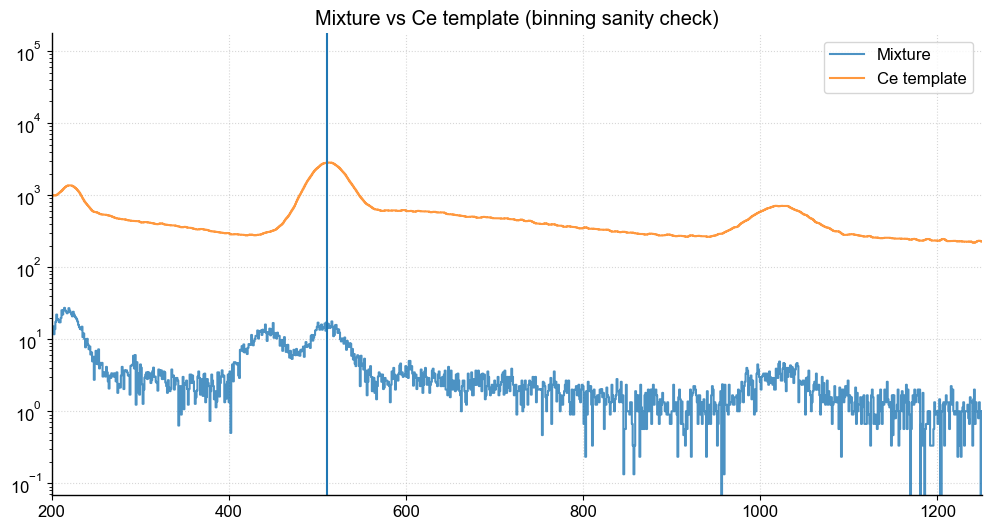

In [37]:
x_keV = np.asarray(mix_spec["bin_centers_kev"], dtype=float)
y_mix = np.asarray(mix_spec["counts_vals"], dtype=float)
y_ce_template = np.asarray(ce_tpl["counts_vals"], dtype=float)

# quick sanity plot: same binning?
plt.figure()
plt.step(x_keV, y_mix, where="mid", label="Mixture", alpha=0.8)
plt.step(ce_tpl["bin_centers_kev"], y_ce_template, where="mid", label="Ce template", alpha=0.8)
plt.yscale("log")
plt.xlim(200, 1250)
plt.axvline(511)
plt.legend()
plt.title("Mixture vs Ce template (binning sanity check)")
plt.show()

# Build Label $\rightarrow$ Activity Truth maps

In [38]:
truth_ce = store.load_ground_truth(exp_ce)["labels"]
truth_ac = store.load_ground_truth(exp_ac)["labels"]

# label -> activity_Bq
ce_truth_bq = {
    lbl: float(truth_ce[lbl]["ce134"]["value"])
    for lbl in truth_ce
    if ("ce134" in truth_ce[lbl]) and (truth_ce[lbl]["ce134"].get("value") is not None)
}

ac_truth_bq = {
    lbl: float(truth_ac[lbl]["ac225"]["value"])
    for lbl in truth_ac
    if ("ac225" in truth_ac[lbl]) and (truth_ac[lbl]["ac225"].get("value") is not None)
}

print("Ce truth entries:", len(ce_truth_bq))
print("Ac truth entries:", len(ac_truth_bq))

Ce truth entries: 10
Ac truth entries: 10


# Initialize and Fit Efficiency Models 

In [39]:
ce_emin, ce_emax = cfg.ce_window.bounds()
ac_emin, ac_emax = cfg.ac_window.bounds()

ce_fit = EfficiencyFitSpec(
    name="ce134_win1022_counts60s_v2",
    label_to_activity=ce_truth_bq,
    model_type="nonparalyzable",          # or "nonparalyzable"
    emin_keV=float(ce_emin),
    emax_keV=float(ce_emax),
    livetime_s=60.0,
    rate_units="counts",
)

ac_fit = EfficiencyFitSpec(
    name="ac225_win_counts60s_v2",  # rename if you want "win218" vs "win440"
    label_to_activity=ac_truth_bq,
    model_type="nonparalyzable",            # or "nonparalyzable"
    emin_keV=float(ac_emin),
    emax_keV=float(ac_emax),
    livetime_s=60.0,
    rate_units="counts",
)

ce_eff_model = fit_efficiency_model(ce_cal, ce_fit)
ac_eff_model = fit_efficiency_model(ac_cal, ac_fit)

print("Ce model:", ce_eff_model.name, ce_eff_model.model_type, ce_eff_model.params)
print("Ac model:", ac_eff_model.name, ac_eff_model.model_type, ac_eff_model.params)


Ce model: ce134_win1022_counts60s_v2 nonparalyzable {'a': 2.1722779095662186, 'b': 3.480697170073751e-06}
Ac model: ac225_win_counts60s_v2 nonparalyzable {'a': 3.4677227169834506, 'b': 6.991402446751088e-08}


### Visualize Fit Relation

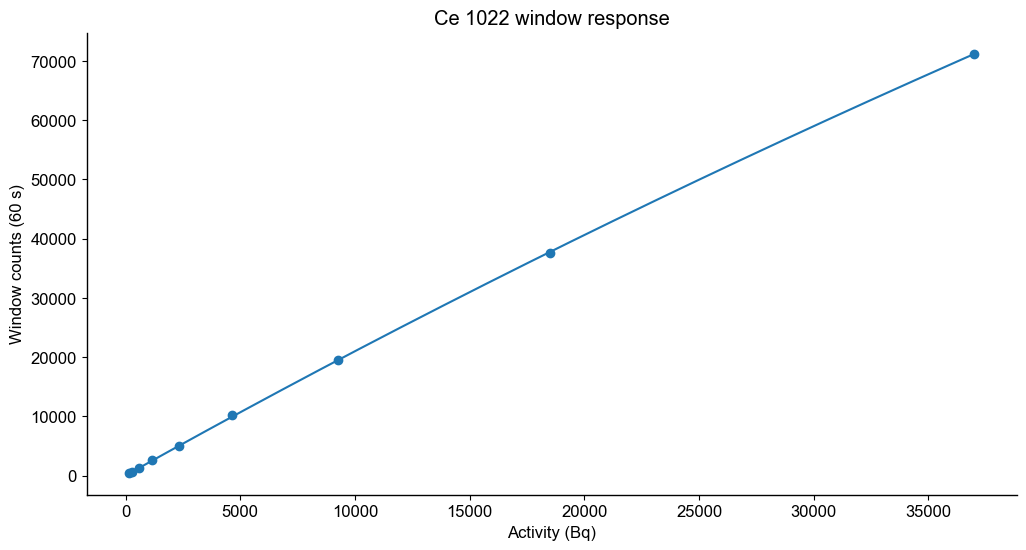

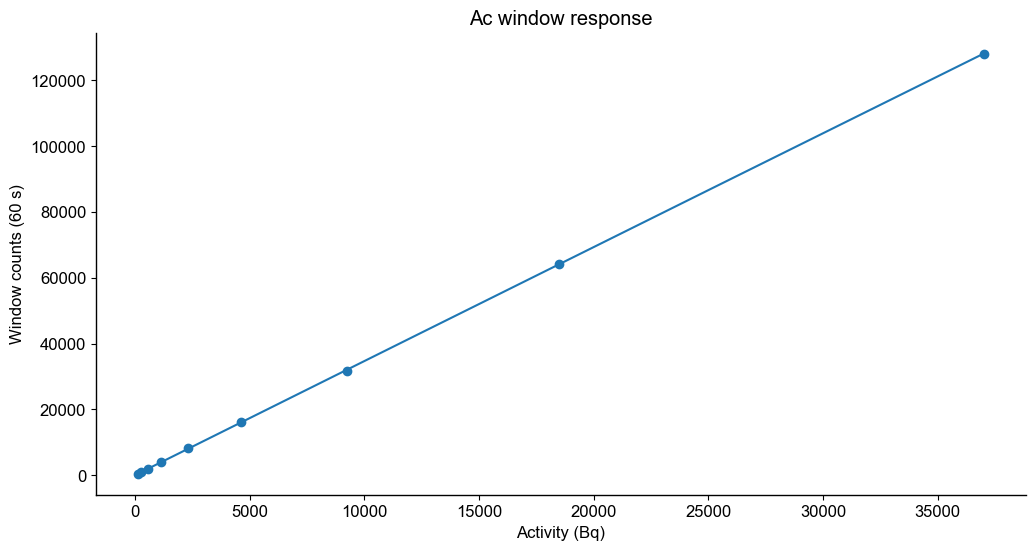

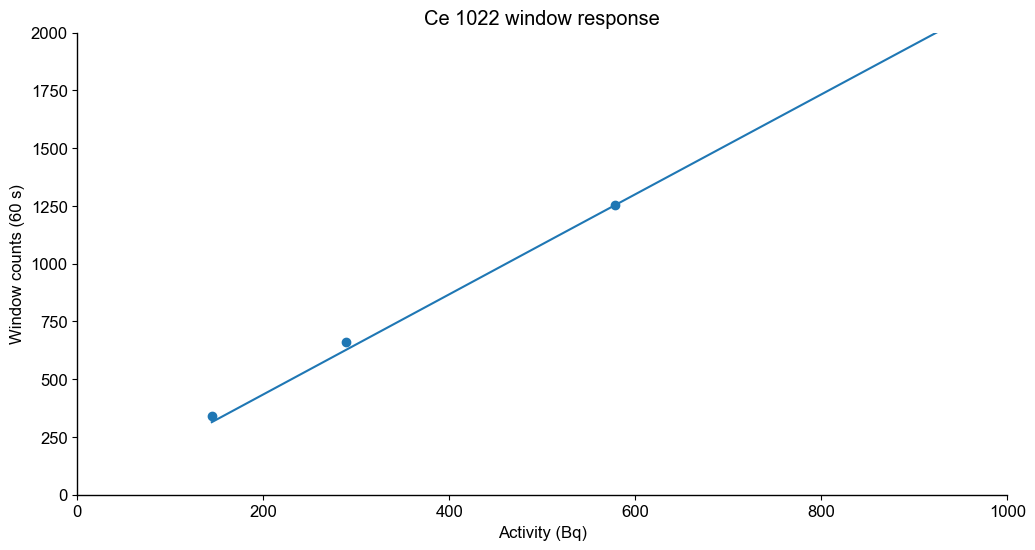

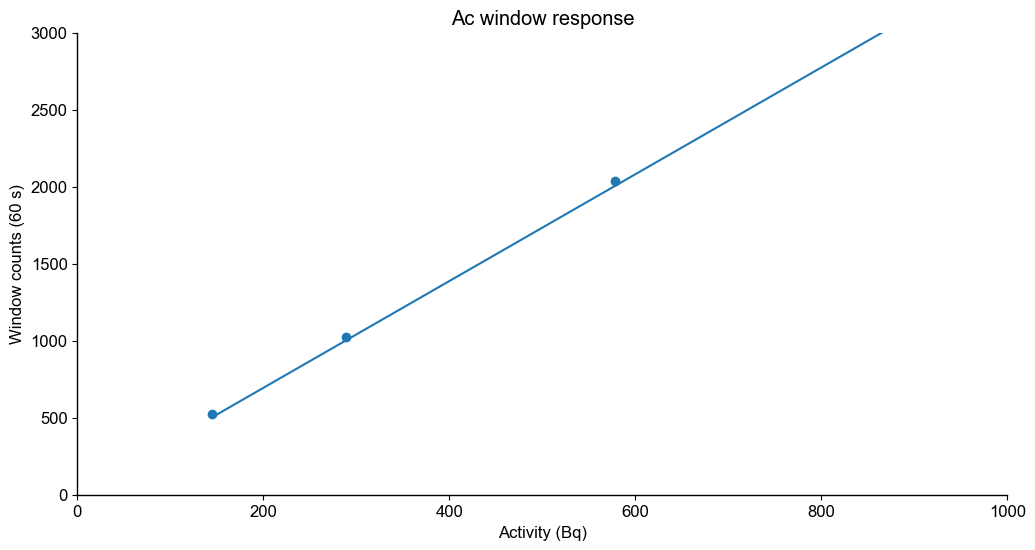

In [40]:
def plot_eff_model_points(model, title, xlim=None, ylim=None):
    A = np.array(model.meta["A_used"], dtype=float)
    R = np.array(model.meta["R_used"], dtype=float)
    a = float(model.params["a"])
    b = float(model.params["b"])

    xs = np.linspace(A.min(), A.max(), 200)
    if model.model_type == "linear":
        ys = a*xs + b
    else:
        ys = (a*xs) / (1 + b*xs)

    plt.figure()
    plt.scatter(A, R)
    plt.plot(xs, ys)
    plt.xlabel("Activity (Bq)")
    plt.ylabel("Window counts (60 s)")
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
    plt.title(title)
    plt.grid()
    plt.show()

plot_eff_model_points(ce_eff_model, "Ce 1022 window response")
plot_eff_model_points(ac_eff_model, "Ac window response")

plot_eff_model_points(ce_eff_model, "Ce 1022 window response", xlim=(0,1000),ylim=(0,2000))
plot_eff_model_points(ac_eff_model, "Ac window response",xlim=(0,1000),ylim=(0,3000))

# Run CutCount

In [41]:
# est, extra, fit_arrays = estimate_ceac_mixture_cutcount(
#     experiment_id=exp_mix,
#     label=mix_label,
#     x_keV=x_keV,
#     y_mix=y_mix,
#     y_ce_template=y_ce_template,
#     ce_eff_model=ce_eff_model,
#     ac_eff_model=ac_eff_model,
#     config=cfg,
#     ce_template_label=ce_template_label,
# )

x_ce_tpl = np.asarray(ce_tpl["bin_centers_kev"], dtype=float)

est, extra, fit_arrays = estimate_ceac_mixture_cutcount(
    experiment_id=exp_mix,
    label=mix_label,
    x_keV=x_keV,
    y_mix=y_mix,
    y_ce_template=y_ce_template,
    x_ce_template_keV=x_ce_tpl,   # <-- new
    ce_eff_model=ce_eff_model,
    ac_eff_model=ac_eff_model,
    config=cfg,
    ce_template_label=ce_template_label,
)

# print("Estimated activities (Bq):", est.activities_bq)
# print("Estimated uncertainties (Bq):", est.uncertainties_bq)
# print("Scale Ce template:", extra["scale_ce_template"])

# plt.figure()
# plt.step()
# plt.step(fit_arrays["x_keV"], fit_arrays["y_mix"], where="mid", label="Mixture", alpha=0.7)
# plt.step(fit_arrays["x_keV"], fit_arrays["y_ce_scaled"], where="mid", label="Scaled Ce template", alpha=0.7)
# plt.step(fit_arrays["x_keV"], fit_arrays["y_residual"], where="mid", label="Residual", alpha=0.9)
# plt.yscale("log")
# plt.xlim(*cfg.roi_keV)
# plt.legend()
# plt.title("Cut-and-count decomposition (Ce→subtract→Ac)")
# plt.show()

# build a richer run_config (adds provenance) before making run_id
run_config = dict(est.diagnostics.get("run_config", {}))
run_config["templates"] = {
    "ce134": {"experiment_id": exp_ce, "cal_tag": cal_tag, "label": ce_template_label}
}
run_config["eff_models"] = {
    "ce": {"name": ce_eff_model.name, "type": ce_eff_model.model_type},
    "ac": {"name": ac_eff_model.name, "type": ac_eff_model.model_type},
}
# store it back into the estimate for provenance
est.diagnostics["run_config"] = run_config

run_id = ArtifactStore.make_run_id(run_config, prefix=cfg.method_tag)

existing = set(store.list_cutcount_runs(exp_mix, mix_label))
if run_id in existing:
    print('exists, as expected, not saved')
else:
    # Save JSON + arrays (arrays optional; requires the artifacts.py patch)
    # store.save_cutcount_estimate(
    #     est,
    #     run_id=run_id,
    #     fit_arrays={
    #         "x_keV": fit_arrays["x_keV"],
    #         "y_mix": fit_arrays["y_mix"],
    #         "y_ce_scaled": fit_arrays["y_ce_scaled"],
    #         "y_residual": fit_arrays["y_residual"],
    #     },
    # )

    # display(fit_arrays)

    store.save_cutcount_estimate(
        est,
        run_id=run_id,
        fit_arrays={
            "x_keV": fit_arrays["x_keV"],
            "y_mix": fit_arrays["y_mix"],

            # native Ce template grid
            # "x_ce_template_keV": fit_arrays["x_ce_template_keV"],
            # "y_ce_template_native": fit_arrays["y_ce_template_native"],

            # resampled template used in subtraction
            "y_template_ce": fit_arrays["y_template_ce"],
            "y_scaled_template_ce": fit_arrays["y_scaled_template_ce"],

            "y_residual": fit_arrays["y_residual"],
        },
    )


    print("Saved run_id:", run_id)

exists, as expected, not saved


In [108]:
est

CutCountEstimate(experiment_id='ANIL_MIX_SD__agg__bkgsub', label='3.906:3.906', activities_bq={'ce134': 157.50938027057887, 'ac225': 146.80959082158057}, uncertainties_bq={'ce134': 8.522216612387346, 'ac225': 6.506714012555535}, diagnostics={'method': 'cutcount_ceac_v3', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_ceac_v3', 'livetime_s': 60.0, 'roi_keV': [200.0, 1250.0], 'windows': {'ce': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'ac': {'center_keV': 440.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [410.10615711252655, 469.89384288747345]}}, 'isos': {'ce': 'ce134', 'ac': 'ac225'}, 'eff_models': {'ce': {'name': 'ce134_win1022_counts60s_v2', 'type': 'nonparalyzable'}, 'ac': {'name': 'ac225_win_counts60s_v2', 'type': 'nonparalyzable'}}, 'templates': {'ce134': {'experiment_id': 'ANIL_CE_SD__agg__bkgsub', 'cal_tag':

# Visualize

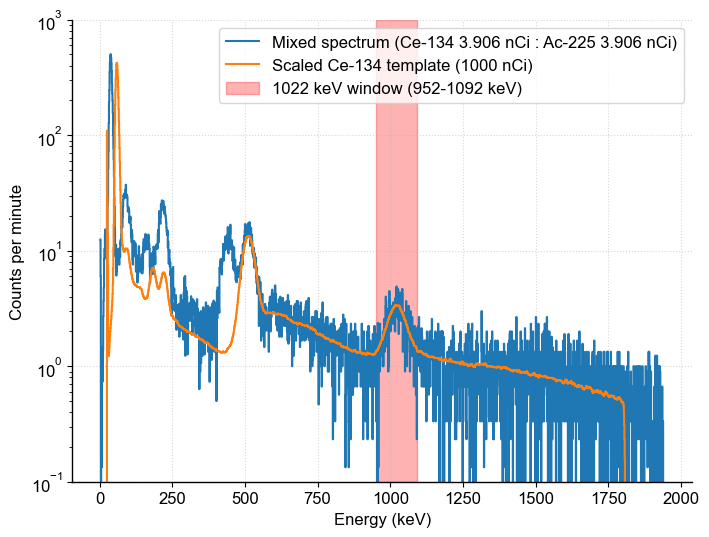

In [104]:
plt.figure()

# plt.step(mix_spec['bin_centers_kev'], mix_spec['counts_vals'])


plt.step(fit_arrays["x_keV"], fit_arrays["y_mix"], where="mid", label="Mixed spectrum (Ce-134 3.906 nCi : Ac-225 3.906 nCi)", alpha=1)
plt.step(fit_arrays["x_keV"], fit_arrays["y_ce_scaled"], where="mid", label="Scaled Ce-134 template (1000 nCi)", alpha= 1, color='C1')

plt.axvspan(952.5647558386412, 1091.4352441613587, color="red", alpha=0.3, label="1022 keV window (952-1092 keV)")

# plt.step(fit_arrays["x_keV"], fit_arrays["y_template_ce"], where="mid", label="og template WRONG x axis", alpha=0.7)
# plt.step(fit_arrays["x_ce_template_keV"], fit_arrays["y_template_ce"], where="mid", label="og template RIGHT x axis", alpha=0.7)

plt.yscale("log")
# plt.xlim(200, 1250)
# plt.axvline(511)

plt.ylabel('Counts per minute')
plt.xlabel('Energy (keV)')
plt.legend()
plt.ylim(0.1,1000)
# plt.xlim(100,2000)
# plt.title("Cut-and-count decomposition (Ce→subtract→Ac)")
plt.show()


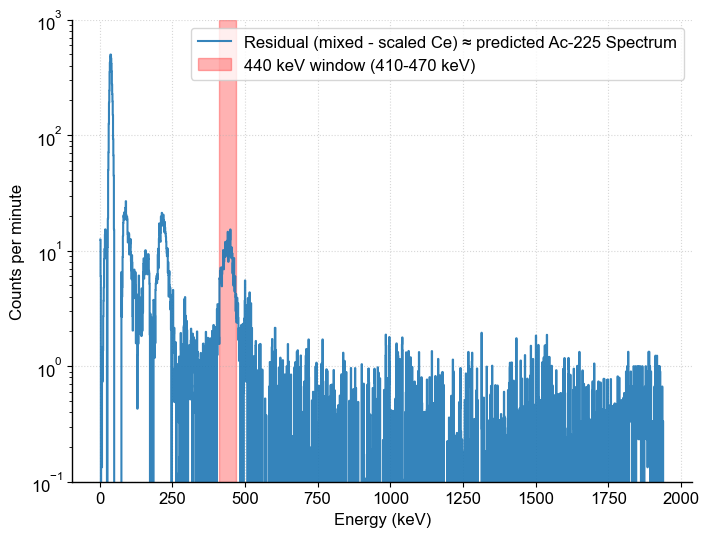

In [107]:
plt.figure()

# plt.step(mix_spec['bin_centers_kev'], mix_spec['counts_vals'])


plt.step(fit_arrays["x_keV"], fit_arrays["y_residual"], where="mid", label="Residual (mixed - scaled Ce) ≈ predicted Ac-225 Spectrum", color='C0', alpha=0.9)
plt.axvspan(410.10615711252655, 469.89384288747345, color="red", alpha=0.3, label="440 keV window (410-470 keV)")

# plt.step(fit_arrays["x_keV"], fit_arrays["y_mix"], where="mid", label="Mixed spectrum (Ce-134 3.906 nCi : Ac-225 3.906 nCi)", alpha=1)
# plt.step(fit_arrays["x_keV"], fit_arrays["y_ce_scaled"], where="mid", label="Scaled Ce-134 template (1000 nCi)", alpha= 1, color='C2')
# plt.step(fit_arrays["x_keV"], fit_arrays["y_residual"], where="mid", label="Residual (mixed - scaled Ce) ≈ predicted Ac-225 Spectrum", color='C1', alpha=0.9)

# plt.step(fit_arrays["x_keV"], fit_arrays["y_template_ce"], where="mid", label="og template WRONG x axis", alpha=0.7)
# plt.step(fit_arrays["x_ce_template_keV"], fit_arrays["y_template_ce"], where="mid", label="og template RIGHT x axis", alpha=0.7)

plt.yscale("log")
# plt.xlim(200, 1250)
# plt.axvline(511)

plt.ylabel('Counts per minute')
plt.xlabel('Energy (keV)')
plt.legend()
plt.ylim(0.1,1000)
# plt.xlim(100,2000)
# plt.title("Cut-and-count decomposition (Ce→subtract→Ac)")
plt.show()


In [ ]:
# fit_arrays = {
#     "x_keV": x_keV,
#     "y_mix": y_mix,
#     "y_template_ce": y_ce_template,
#     "y_residual": extra["y_residual"],
#     "y_scaled_template_ce": extra["scale_ce"] * y_ce_template,
# }

# run_id = ArtifactStore.make_run_id(est.diagnostics["run_config"], prefix=cfg.method_tag)
# # store.save_cutcount_estimate(est, run_id=run_id)  # + fit_arrays if you add the artifacts patch
# store.save_cutcount_estimate(est, run_id=run_id, fit_arrays=fit_arrays)

# Loop to Produce Estimations on Mixed Samples

In [ ]:
mix_labels = list(mix_cal.labels)
ce_labels  = list(ce_cal.labels)

for mix_label in mix_labels:
    mix_spec = mix_cal.calibrated[mix_label]
    x_keV = np.asarray(mix_spec["bin_centers_kev"], dtype=float)
    y_mix = np.asarray(mix_spec["counts_vals"], dtype=float)

    for ce_template_label in ce_labels:
        # skip if already saved for this mix label with same run_id
        ce_tpl = ce_cal.calibrated[ce_template_label]
        y_ce_template = np.asarray(ce_tpl["counts_vals"], dtype=float)

        # run
        x_ce_tpl = np.asarray(ce_tpl["bin_centers_kev"], dtype=float)

        est, extra, fit_arrays = estimate_ceac_mixture_cutcount(
            experiment_id=exp_mix,
            label=mix_label,
            x_keV=x_keV,
            y_mix=y_mix,
            y_ce_template=y_ce_template,
            x_ce_template_keV=x_ce_tpl,   # <-- new
            ce_eff_model=ce_eff_model,
            ac_eff_model=ac_eff_model,
            config=cfg,
            ce_template_label=ce_template_label,
        )

        run_config = dict(est.diagnostics.get("run_config", {}))
        run_config["templates"] = {
            "ce134": {"experiment_id": exp_ce, "cal_tag": cal_tag, "label": ce_template_label}
        }
        run_config["eff_models"] = {
            "ce": {"name": ce_eff_model.name, "type": ce_eff_model.model_type},
            "ac": {"name": ac_eff_model.name, "type": ac_eff_model.model_type},
        }
        est.diagnostics["run_config"] = run_config

        run_id = ArtifactStore.make_run_id(run_config, prefix=cfg.method_tag)

        # skip if json exists
        existing = set(store.list_cutcount_runs(exp_mix, mix_label))
        if run_id in existing:
            print('exists, as expected')
            continue

        store.save_cutcount_estimate(
            est,
            run_id=run_id,
            fit_arrays={
                "x_keV": fit_arrays["x_keV"],
                "y_mix": fit_arrays["y_mix"],
                
                # resampled template used in subtraction
                "y_template_ce": fit_arrays["y_template_ce"],
                "y_scaled_template_ce": fit_arrays["y_scaled_template_ce"],

                "y_residual": fit_arrays["y_residual"],
            },
        )

print("Sweep done.")


exists, as expected
Sweep done.


# View `runs` table?
- Isn't this meant for `05_persisted.ipynb`?

In [ ]:
df_cc = store.cutcount_runs_table(exp_mix)
# print(df_cc.shape)
df_cc.sort_values(["label", "saved_at"]).head(20)

(80, 10)


,activity_units,eff_models,experiment_id,label,method_tag,npz_exists,roi_keV,run_id,saved_at,templates
0,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v3,True,"[200.0, 1250.0]",cutcount_ceac_v3__45d037df2f,2026-02-19T15:10:56.911877+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...
1,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v3,True,"[200.0, 1250.0]",cutcount_ceac_v3__194a360fc7,2026-02-19T15:15:14.072860+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...
2,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v3,True,"[200.0, 1250.0]",cutcount_ceac_v3__9edcc136b6,2026-02-19T15:15:14.080447+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...
3,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v3,True,"[200.0, 1250.0]",cutcount_ceac_v3__feed226c67,2026-02-19T15:15:14.085513+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...
4,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v3,True,"[200.0, 1250.0]",cutcount_ceac_v3__7e10acdeb4,2026-02-19T15:15:14.093205+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...
5,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v3,True,"[200.0, 1250.0]",cutcount_ceac_v3__21356c6531,2026-02-19T15:15:14.098203+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...
6,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v3,True,"[200.0, 1250.0]",cutcount_ceac_v3__78eb174128,2026-02-19T15:15:14.103443+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...
7,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v3,True,"[200.0, 1250.0]",cutcount_ceac_v3__bead71ac3b,2026-02-19T15:15:14.108987+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...
8,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v3,True,"[200.0, 1250.0]",cutcount_ceac_v3__b1f2eef094,2026-02-19T15:15:14.114986+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...
9,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v3,True,"[200.0, 1250.0]",cutcount_ceac_v3__ce66436fa3,2026-02-19T15:15:14.120481+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...


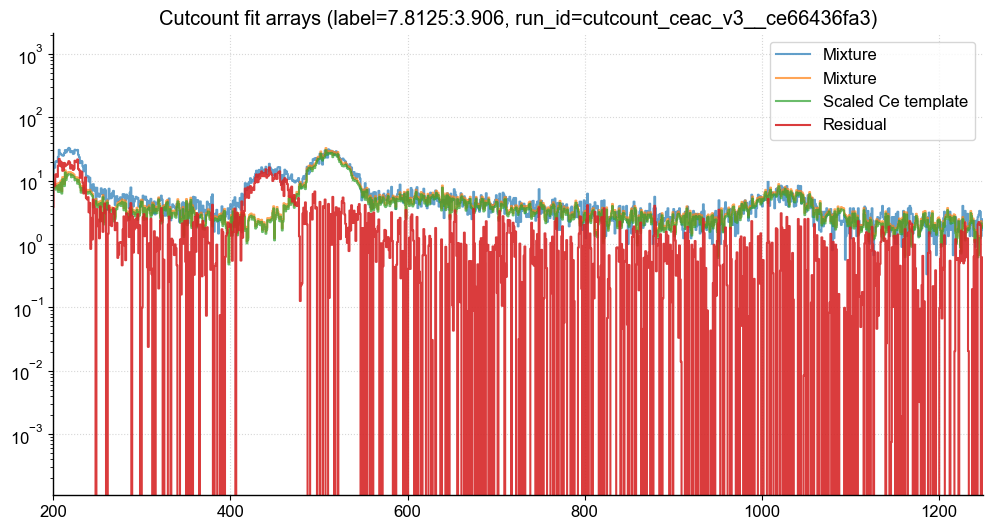

In [ ]:
# pick one row
row = df_cc.sort_values("saved_at").iloc[-1]
lab = row["label"]
rid = row["run_id"]

arr = store.load_cutcount_fit_arrays(exp_mix, lab, run_id=rid)

plt.figure()
plt.step(arr["x_keV"], arr["y_mix"], where="mid", label="Mixture", alpha=0.7)
plt.step(arr["x_keV"], arr["y_template_ce"], where="mid", label="Mixture", alpha=0.7)
plt.step(arr["x_keV"], arr["y_scaled_template_ce"], where="mid", label="Scaled Ce template", alpha=0.7)
plt.step(arr["x_keV"], arr["y_residual"], where="mid", label="Residual", alpha=0.9)
plt.yscale("log")
plt.xlim(*cfg.roi_keV)
plt.legend()
plt.title(f"Cutcount fit arrays (label={lab}, run_id={rid})")
plt.show()


# Loop to Produce Estimations on pure Ce Samples

In [ ]:
cfg_ce = CeAcCutCountConfig(
    ce_window=EnergyWindowSpec(center_keV=1022.0, resolution_pct_fwhm=8.0, nsigma=2.0))

In [ ]:
ce_labels = list(ce_cal.labels)
ce_window = EnergyWindowSpec(center_keV=1022.0, resolution_pct_fwhm=8.0, nsigma=2.0)

method_tag = "cutcount_single_v1"

for ce_est_label in ce_labels:
    ce_spec = ce_cal.calibrated[ce_est_label]
    x_keV = np.asarray(ce_spec["bin_centers_kev"], dtype=float)
    y_counts = np.asarray(ce_spec["counts_vals"], dtype=float)

    est_ce, extra_ce = estimate_single_isotope_cutcount(
        experiment_id=exp_ce,
        label=ce_est_label,
        iso="ce134",
        x_keV=x_keV,
        y_counts=y_counts,
        window=ce_window,
        eff_model=ce_eff_model,
    )

    run_config = {
        "method": method_tag,
        "iso": "ce134",
        "window": ce_window.describe(),
        "eff_models": {"ce": {"name": ce_eff_model.name, "type": ce_eff_model.model_type}},
    }
    est_ce.diagnostics["run_config"] = run_config
    run_id = ArtifactStore.make_run_id(run_config, prefix=method_tag)

    existing = set(store.list_cutcount_runs(exp_ce, ce_est_label))
    if run_id in existing:
        continue

    store.save_cutcount_estimate(
        est_ce,
        run_id=run_id,
        fit_arrays={"x_keV": x_keV, "y_counts": y_counts},
    )

    display(est_ce)

print("Pure-Ce cutcount sweep done.")


CutCountEstimate(experiment_id='ANIL_CE_SD__agg__bkgsub', label='1.95312', activities_bq={'ce134': 83.4236133676249}, uncertainties_bq={'ce134': 6.199775144843998}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ce134', 'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'eff_models': {'ce': {'name': 'ce134_win1022_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'counts_window': 181.16666666666666, 'sigma_counts_window': 13.459816739713311, 'eff_model_name': 'ce134_win1022_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 2.1722779095662186, 'b': 3.480697170073751e-06}}})

CutCountEstimate(experiment_id='ANIL_CE_SD__agg__bkgsub', label='1000', activities_bq={'ce134': 37025.579323772785}, uncertainties_bq={'ce134': 156.58924231233456}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ce134', 'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'eff_models': {'ce': {'name': 'ce134_win1022_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'counts_window': 71247.79999999999, 'sigma_counts_window': 266.92283529140025, 'eff_model_name': 'ce134_win1022_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 2.1722779095662186, 'b': 3.480697170073751e-06}}})

CutCountEstimate(experiment_id='ANIL_CE_SD__agg__bkgsub', label='125', activities_bq={'ce134': 4746.068259990813}, uncertainties_bq={'ce134': 47.9052321838248}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ce134', 'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'eff_models': {'ce': {'name': 'ce134_win1022_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'counts_window': 10142.233333333334, 'sigma_counts_window': 100.70865570214575, 'eff_model_name': 'ce134_win1022_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 2.1722779095662186, 'b': 3.480697170073751e-06}}})

CutCountEstimate(experiment_id='ANIL_CE_SD__agg__bkgsub', label='15.625', activities_bq={'ce134': 578.1899581104849}, uncertainties_bq={'ce134': 16.363917871282606}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ce134', 'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'eff_models': {'ce': {'name': 'ce134_win1022_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'counts_window': 1253.4666666666667, 'sigma_counts_window': 35.40433118513421, 'eff_model_name': 'ce134_win1022_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 2.1722779095662186, 'b': 3.480697170073751e-06}}})

CutCountEstimate(experiment_id='ANIL_CE_SD__agg__bkgsub', label='250', activities_bq={'ce134': 9295.452662347701}, uncertainties_bq={'ce134': 68.61529896844505}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ce134', 'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'eff_models': {'ce': {'name': 'ce134_win1022_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'counts_window': 19559.466666666667, 'sigma_counts_window': 139.85516317485983, 'eff_model_name': 'ce134_win1022_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 2.1722779095662186, 'b': 3.480697170073751e-06}}})

...

CutCountEstimate(experiment_id='ANIL_CE_SD__agg__bkgsub', label='31.25', activities_bq={'ce134': 1174.1196763038936}, uncertainties_bq={'ce134': 23.391353254111706}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ce134', 'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'eff_models': {'ce': {'name': 'ce134_win1022_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'counts_window': 2540.133333333333, 'sigma_counts_window': 50.39973544904113, 'eff_model_name': 'ce134_win1022_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 2.1722779095662186, 'b': 3.480697170073751e-06}}})

CutCountEstimate(experiment_id='ANIL_CE_SD__agg__bkgsub', label='500', activities_bq={'ce134': 18397.31119916921}, uncertainties_bq={'ce134': 101.00750466069297}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ce134', 'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'eff_models': {'ce': {'name': 'ce134_win1022_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'counts_window': 37558.96666666667, 'sigma_counts_window': 193.80135878436627, 'eff_model_name': 'ce134_win1022_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 2.1722779095662186, 'b': 3.480697170073751e-06}}})

CutCountEstimate(experiment_id='ANIL_CE_SD__agg__bkgsub', label='62.5', activities_bq={'ce134': 2301.609549578175}, uncertainties_bq={'ce134': 32.942471028206775}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ce134', 'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'eff_models': {'ce': {'name': 'ce134_win1022_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'counts_window': 4960.0, 'sigma_counts_window': 70.42726744663604, 'eff_model_name': 'ce134_win1022_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 2.1722779095662186, 'b': 3.480697170073751e-06}}})

CutCountEstimate(experiment_id='ANIL_CE_SD__agg__bkgsub', label='7.8125', activities_bq={'ce134': 305.04206857337107}, uncertainties_bq={'ce134': 11.868982322348591}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ce134', 'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'eff_models': {'ce': {'name': 'ce134_win1022_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 1022.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [952.5647558386412, 1091.4352441613587]}, 'counts_window': 661.9333333333334, 'sigma_counts_window': 25.728065091128276, 'eff_model_name': 'ce134_win1022_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 2.1722779095662186, 'b': 3.480697170073751e-06}}})

Pure-Ce cutcount sweep done.


# Loop to Produce Estimations on pure Ac Samples

In [ ]:
ac_labels = list(ac_cal.labels)
ac_window = EnergyWindowSpec(center_keV=218.0, resolution_pct_fwhm=8.0, nsigma=2.0)

method_tag = "cutcount_single_v1"

for ac_est_label in ac_labels:
    ac_spec = ac_cal.calibrated[ac_est_label]   
    x_keV = np.asarray(ac_spec["bin_centers_kev"], dtype=float)
    y_counts = np.asarray(ac_spec["counts_vals"], dtype=float)

    est_ac, extra_ac = estimate_single_isotope_cutcount(
        experiment_id=exp_ac,
        label=ac_est_label,
        iso="ac225",                           
        x_keV=x_keV,
        y_counts=y_counts,
        window=ac_window,
        eff_model=ac_eff_model,
    )

    run_config = {
        "method": method_tag,
        "iso": "ac225",
        "window": ac_window.describe(),
        "eff_models": {"ac": {"name": ac_eff_model.name, "type": ac_eff_model.model_type}},
    }
    est_ac.diagnostics["run_config"] = run_config   
    run_id = ArtifactStore.make_run_id(run_config, prefix=method_tag)

    existing = set(store.list_cutcount_runs(exp_ac, ac_est_label))
    if run_id in existing:
        continue

    store.save_cutcount_estimate(
        est_ac,
        run_id=run_id,
        fit_arrays={"x_keV": x_keV, "y_counts": y_counts},
    )

    display(est_ac)

print("Pure Ac cutcount sweep done.")

CutCountEstimate(experiment_id='ANIL_AC_SD__agg__bkgsub', label='1.95312', activities_bq={'ac225': 77.42875523785354}, uncertainties_bq={'ac225': 4.725333699425209}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ac225', 'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'eff_models': {'ac': {'name': 'ac225_win_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'counts_window': 268.50000000000006, 'sigma_counts_window': 16.38596960817394, 'eff_model_name': 'ac225_win_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 3.4677227169834506, 'b': 6.991402446751088e-08}}})

CutCountEstimate(experiment_id='ANIL_AC_SD__agg__bkgsub', label='1000', activities_bq={'ac225': 33986.4475552343}, uncertainties_bq={'ac225': 99.35203750157469}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ac225', 'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'eff_models': {'ac': {'name': 'ac225_win_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'counts_window': 117576.2, 'sigma_counts_window': 342.89386112906715, 'eff_model_name': 'ac225_win_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 3.4677227169834506, 'b': 6.991402446751088e-08}}})

CutCountEstimate(experiment_id='ANIL_AC_SD__agg__bkgsub', label='125', activities_bq={'ac225': 4402.638979844395}, uncertainties_bq={'ac225': 35.64797317856812}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ac225', 'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'eff_models': {'ac': {'name': 'ac225_win_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'counts_window': 15262.433333333332, 'sigma_counts_window': 123.54122119087755, 'eff_model_name': 'ac225_win_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 3.4677227169834506, 'b': 6.991402446751088e-08}}})

CutCountEstimate(experiment_id='ANIL_AC_SD__agg__bkgsub', label='15.625', activities_bq={'ac225': 574.3865583484906}, uncertainties_bq={'ac225': 12.870816901948292}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ac225', 'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'eff_models': {'ac': {'name': 'ac225_win_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'counts_window': 1991.7333333333331, 'sigma_counts_window': 44.6288397040897, 'eff_model_name': 'ac225_win_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 3.4677227169834506, 'b': 6.991402446751088e-08}}})

CutCountEstimate(experiment_id='ANIL_AC_SD__agg__bkgsub', label='250', activities_bq={'ac225': 8845.196749158029}, uncertainties_bq={'ac225': 50.55152903536977}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ac225', 'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'eff_models': {'ac': {'name': 'ac225_win_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'counts_window': 30653.73333333333, 'sigma_counts_window': 175.08207599104293, 'eff_model_name': 'ac225_win_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 3.4677227169834506, 'b': 6.991402446751088e-08}}})

...

CutCountEstimate(experiment_id='ANIL_AC_SD__agg__bkgsub', label='31.25', activities_bq={'ac225': 1144.1853038425365}, uncertainties_bq={'ac225': 18.16678643004397}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ac225', 'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'eff_models': {'ac': {'name': 'ac225_win_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'counts_window': 3967.4000000000005, 'sigma_counts_window': 62.98730030728417, 'eff_model_name': 'ac225_win_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 3.4677227169834506, 'b': 6.991402446751088e-08}}})

CutCountEstimate(experiment_id='ANIL_AC_SD__agg__bkgsub', label='500', activities_bq={'ac225': 16911.277516741007}, uncertainties_bq={'ac225': 69.95774371933325}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ac225', 'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'eff_models': {'ac': {'name': 'ac225_win_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'counts_window': 58574.36666666666, 'sigma_counts_window': 242.02141778501064, 'eff_model_name': 'ac225_win_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 3.4677227169834506, 'b': 6.991402446751088e-08}}})

CutCountEstimate(experiment_id='ANIL_AC_SD__agg__bkgsub', label='62.5', activities_bq={'ac225': 2270.2649599111883}, uncertainties_bq={'ac225': 25.592898961704794}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ac225', 'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'eff_models': {'ac': {'name': 'ac225_win_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'counts_window': 7871.4, 'sigma_counts_window': 88.72091072571335, 'eff_model_name': 'ac225_win_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 3.4677227169834506, 'b': 6.991402446751088e-08}}})

CutCountEstimate(experiment_id='ANIL_AC_SD__agg__bkgsub', label='7.8125', activities_bq={'ac225': 267.240892652336}, uncertainties_bq={'ac225': 8.77892717663379}, diagnostics={'method': 'cutcount_single_v1', 'livetime_s': 60.0, 'run_config': {'method': 'cutcount_single_v1', 'iso': 'ac225', 'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'eff_models': {'ac': {'name': 'ac225_win_counts60s_v2', 'type': 'nonparalyzable'}}}, 'extra': {'window': {'center_keV': 218.0, 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'emin_keV': None, 'emax_keV': None, 'bounds_keV': [203.18895966029723, 232.81104033970277]}, 'counts_window': 926.7, 'sigma_counts_window': 30.44174765022534, 'eff_model_name': 'ac225_win_counts60s_v2', 'eff_model_type': 'nonparalyzable', 'eff_model_params': {'a': 3.4677227169834506, 'b': 6.991402446751088e-08}}})

Pure Ac cutcount sweep done.
